<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Yacht_Hydrodynamics_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Yatch Hydrodynamics Dataset**

The **Yacht Hydrodynamics Dataset** is a dataset widely used in regression and machine learning projects. It is available at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/yacht+hydrodynamics), [github](https://github.com/ajx42/Yacht-Hydrodynamics-Linear-Regression-?utm_source=chatgpt.com), [mlbazaar](https://mlbazaar.github.io/dataset/LL0-uci-yacht-hydrodynamics?utm_source=chatgpt.com). The Yacht Hydrodynamics Dataset is a classic regression dataset used in naval hydrodynamics to predict the residuary resistance of yacht hulls based on geometric and dynamic parameters.

## **Overview**  
This dataset, also known as the *Delft dataset*, originates from the **Delft Ship Hydromechanics Laboratory**. It was used to predict the **hydrodynamic performance** of sailing yachts based on their dimensions and speed. The dataset contains **308 full-scale experiments** conducted with **22 different hull forms**, derived from a base design similar to the "Standfast 43" by designer Frans Maas.  

## **Dataset Structure**  

- **Instances**: 308  
- **Predictor variables** (all dimensionless):  
  1. Longitudinal position of the center of buoyancy  
  2. Prismatic coefficient  
  3. Length-displacement ratio  
  4. Beam-draught ratio  
  5. Length-beam ratio  
  6. Froude number  
- **Target variable**: Residuary resistance per unit weight of displacement  
- **Missing values**: None *(Source: Turnock et al.)*  

## **Common Applications**  

This dataset is frequently used to:  
- Evaluate linear and nonlinear regression models.  
- Apply neural networks and machine learning techniques to predict residuary resistance.  
- Study the relationship between hull geometric parameters and hydrodynamic performance.  

*For example, [Neural Designer](https://www.neuraldesigner.com/learning/examples/yacht-hydrodynamics-modeling/) built a machine learning model to predict yacht hydrodynamic performance based on hull geometry coefficients and the Froude number.*  

## **Access and Additional Resources**  

- **Direct download**: Available via the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/yacht+hydrodynamics).  
- **Python implementations**: See examples on GitHub, like [this repository](https://github.com/ajx42/Yacht-Hydrodynamics-Linear-Regression), which applies linear regression using NumPy, Statsmodels, and Matplotlib.  


## Load the Dataset

In this step we are going to load the libraries and the naval data file from URL.

---
**Load Libraries**

---

In [64]:
# Load libraries
import numpy
from numpy import arange
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

---
**Load the dataset**

---

In [2]:
!wget -O /content/sample_data/yacht_hydrodynamics.data https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data

--2025-04-22 07:32:16--  https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/sample_data/yacht_hydrodynamics.data’

/content/sample_dat     [ <=>                ]  11.22K  --.-KB/s    in 0s      

2025-04-22 07:32:18 (87.2 MB/s) - ‘/content/sample_data/yacht_hydrodynamics.data’ saved [11487]



In [4]:
# Load the dataset
filename = '/content/sample_data/yacht_hydrodynamics.data'

# Column names based on the dataset description
column_names = [
    "Longitudinal_position_of_COB",  # Center of Buoyancy
    "Prismatic_coefficient",
    "Length_displacement_ratio",
    "Beam_draught_ratio",
    "Length_beam_ratio",
    "Froude_number",
    "Residuary_resistance"
]


# Load the dataset
df = pd.read_csv(filename, sep=r'\s+', names=column_names)

# Preview the first few rows
print(df.head())


   Longitudinal_position_of_COB  Prismatic_coefficient  \
0                          -2.3                  0.568   
1                          -2.3                  0.568   
2                          -2.3                  0.568   
3                          -2.3                  0.568   
4                          -2.3                  0.568   

   Length_displacement_ratio  Beam_draught_ratio  Length_beam_ratio  \
0                       4.78                3.99               3.17   
1                       4.78                3.99               3.17   
2                       4.78                3.99               3.17   
3                       4.78                3.99               3.17   
4                       4.78                3.99               3.17   

   Froude_number  Residuary_resistance  
0          0.125                  0.11  
1          0.150                  0.27  
2          0.175                  0.47  
3          0.200                  0.78  
4          0.225   

1. The dataset uses whitespace as the delimiter, so delim_whitespace=True (deprecated by sep=r'\s+') is needed.

2. There are no missing values, so you can go straight into exploration or modeling after this.


## Summarize the Dataset

We can now take a closer look at our loaded data. We can get a quick idea of how many instances (rows) and how many attributes (columns) the
data contains with the shape property.

---
**Data Shape**

---

In [5]:
# shape
print(df.shape)

(308, 7)


We have 308 instances to work with and can confirm the data has 7 attributes.

---
**Data Types**

---

In [7]:
# types
print(df.dtypes)

Longitudinal_position_of_COB    float64
Prismatic_coefficient           float64
Length_displacement_ratio       float64
Beam_draught_ratio              float64
Length_beam_ratio               float64
Froude_number                   float64
Residuary_resistance            float64
dtype: object


---
**Show first rows**

---

It is also always a good idea to actually eyeball your data.

In [8]:
# head
print(df.head(20))

    Longitudinal_position_of_COB  Prismatic_coefficient  \
0                           -2.3                  0.568   
1                           -2.3                  0.568   
2                           -2.3                  0.568   
3                           -2.3                  0.568   
4                           -2.3                  0.568   
5                           -2.3                  0.568   
6                           -2.3                  0.568   
7                           -2.3                  0.568   
8                           -2.3                  0.568   
9                           -2.3                  0.568   
10                          -2.3                  0.568   
11                          -2.3                  0.568   
12                          -2.3                  0.568   
13                          -2.3                  0.568   
14                          -2.3                  0.569   
15                          -2.3                  0.569 

---
**Statistical Summary**

---

Now we can take a look at a summary of each attribute. This includes the count, mean, the min and max values as well as some percentiles.



In [9]:
# Statistical Summary
print(pd.DataFrame(df).describe())

       Longitudinal_position_of_COB  Prismatic_coefficient  \
count                    308.000000             308.000000   
mean                      -2.381818               0.564136   
std                        1.513219               0.023290   
min                       -5.000000               0.530000   
25%                       -2.400000               0.546000   
50%                       -2.300000               0.565000   
75%                       -2.300000               0.574000   
max                        0.000000               0.600000   

       Length_displacement_ratio  Beam_draught_ratio  Length_beam_ratio  \
count                 308.000000          308.000000         308.000000   
mean                    4.788636            3.936818           3.206818   
std                     0.253057            0.548193           0.247998   
min                     4.340000            2.810000           2.730000   
25%                     4.770000            3.750000           3.1

**1. Longitudinal Position of COB (Center of Buoyancy)**
- **Range**: `-5.0` to `0.0` (dimensionless)
- **Mean**: `-2.38` ± `1.51` (high variability)
- **Distribution**:  
  - 50% of values cluster around `-2.4` to `-2.3` (left-skewed).  
  - Minimum (`-5.0`) is an outlier compared to the IQR.

**2. Prismatic Coefficient**
- **Range**: `0.53` to `0.60` (dimensionless)
- **Mean**: `0.564` ± `0.023` (low variability)
- **Insight**:  
  - Tight distribution (std ≈ 2.3% of mean), suggesting hull designs follow similar volumetric efficiency principles.

**3. Length-Displacement Ratio**
- **Range**: `4.34` to `5.14`
- **Mean**: `4.79` ± `0.25`
- **Notable**:  
  - 75th percentile (`5.1`) close to max (`5.14`), indicating few high-ratio designs.

**4. Beam-Draught Ratio**
- **Range**: `2.81` to `5.35`
- **Mean**: `3.94` ± `0.55`
- **Interpretation**:  
  - Wider spread (std ≈ 14% of mean) reflects diverse hull shapes (e.g., shallow vs. deep drafts).

**5. Length-Beam Ratio**
- **Range**: `2.73` to `3.64`
- **Mean**: `3.21` ± `0.25`
- **Pattern**:  
  - 50% of yachts have a ratio of `3.15` (common design stability standard).

**6. Froude Number**
- **Range**: `0.125` to `0.45`
- **Mean**: `0.288` ± `0.101`
- **Implications**:  
  - Values < `0.4` suggest most tests were in *displacement mode* (non-planing hulls).

**7. Residuary Resistance (Target Variable)**
- **Range**: `0.01` to `62.42` (unit: per weight of displacement)
- **Mean**: `10.50` ± `15.16`
- **Distribution**:  
  - Highly right-skewed (mean ≫ median `3.065`).  
  - 75th percentile (`12.82`) << max (`62.42`), indicating extreme outliers (possible high-speed/high-resistance cases).

### **Critical Insights**
1. **Outliers Alert**:  
   - `Residuary_resistance` has extreme values (max ≈ 10× 75th percentile). Consider log-transform for regression models.
2. **Design Uniformity**:  
   - Low std in `Prismatic_coefficient` and `Length_beam_ratio` implies standardized hull design practices.
3. **Speed Regimes**:  
   - `Froude_number` suggests most data is for low-speed hydrodynamics (sub-critical flow).

### **Recommendations for Modeling**
- **Preprocessing**:  
  - Scale features (e.g., `StandardScaler` due to varying ranges).  
  - Log-transform the target variable to handle skewness.
- **Feature Importance**:  
  - Prioritize `Beam_draught_ratio` and `Froude_number` (higher variability likely correlates with resistance).
- **Algorithms**:  
  - Start with **Random Forest** or **Gradient Boosting** to handle non-linear relationships.

### **Python Quick Check for Skewness**
```python
import seaborn as sns
sns.histplot(data=df, x="Residuary_resistance", kde=True)
```
*Expected: Heavy right tail → confirm log-transform need.*


---
**Check Skewness**

---

<Axes: xlabel='Residuary_resistance', ylabel='Count'>

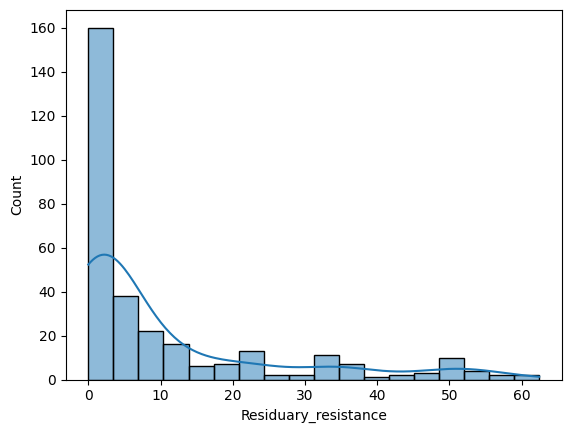

In [11]:
import seaborn as sns
sns.histplot(data=df, x="Residuary_resistance", kde=True)

## Data Visualization

We now have a basic idea about the data. We need to extend this with some visualizations. We
are going to look at two types of plots:
- Univariate plots to better understand each attribute.
- Multivariate plots to better understand the relationships between attributes.


---
**Univariate Plots: Histogram**

---

Let’s look at visualizations of individual attributes. It is often useful to look at your data
using multiple different visualizations in order to spark ideas. Let’s look at histograms of each
attribute to get a sense of the data distributions.

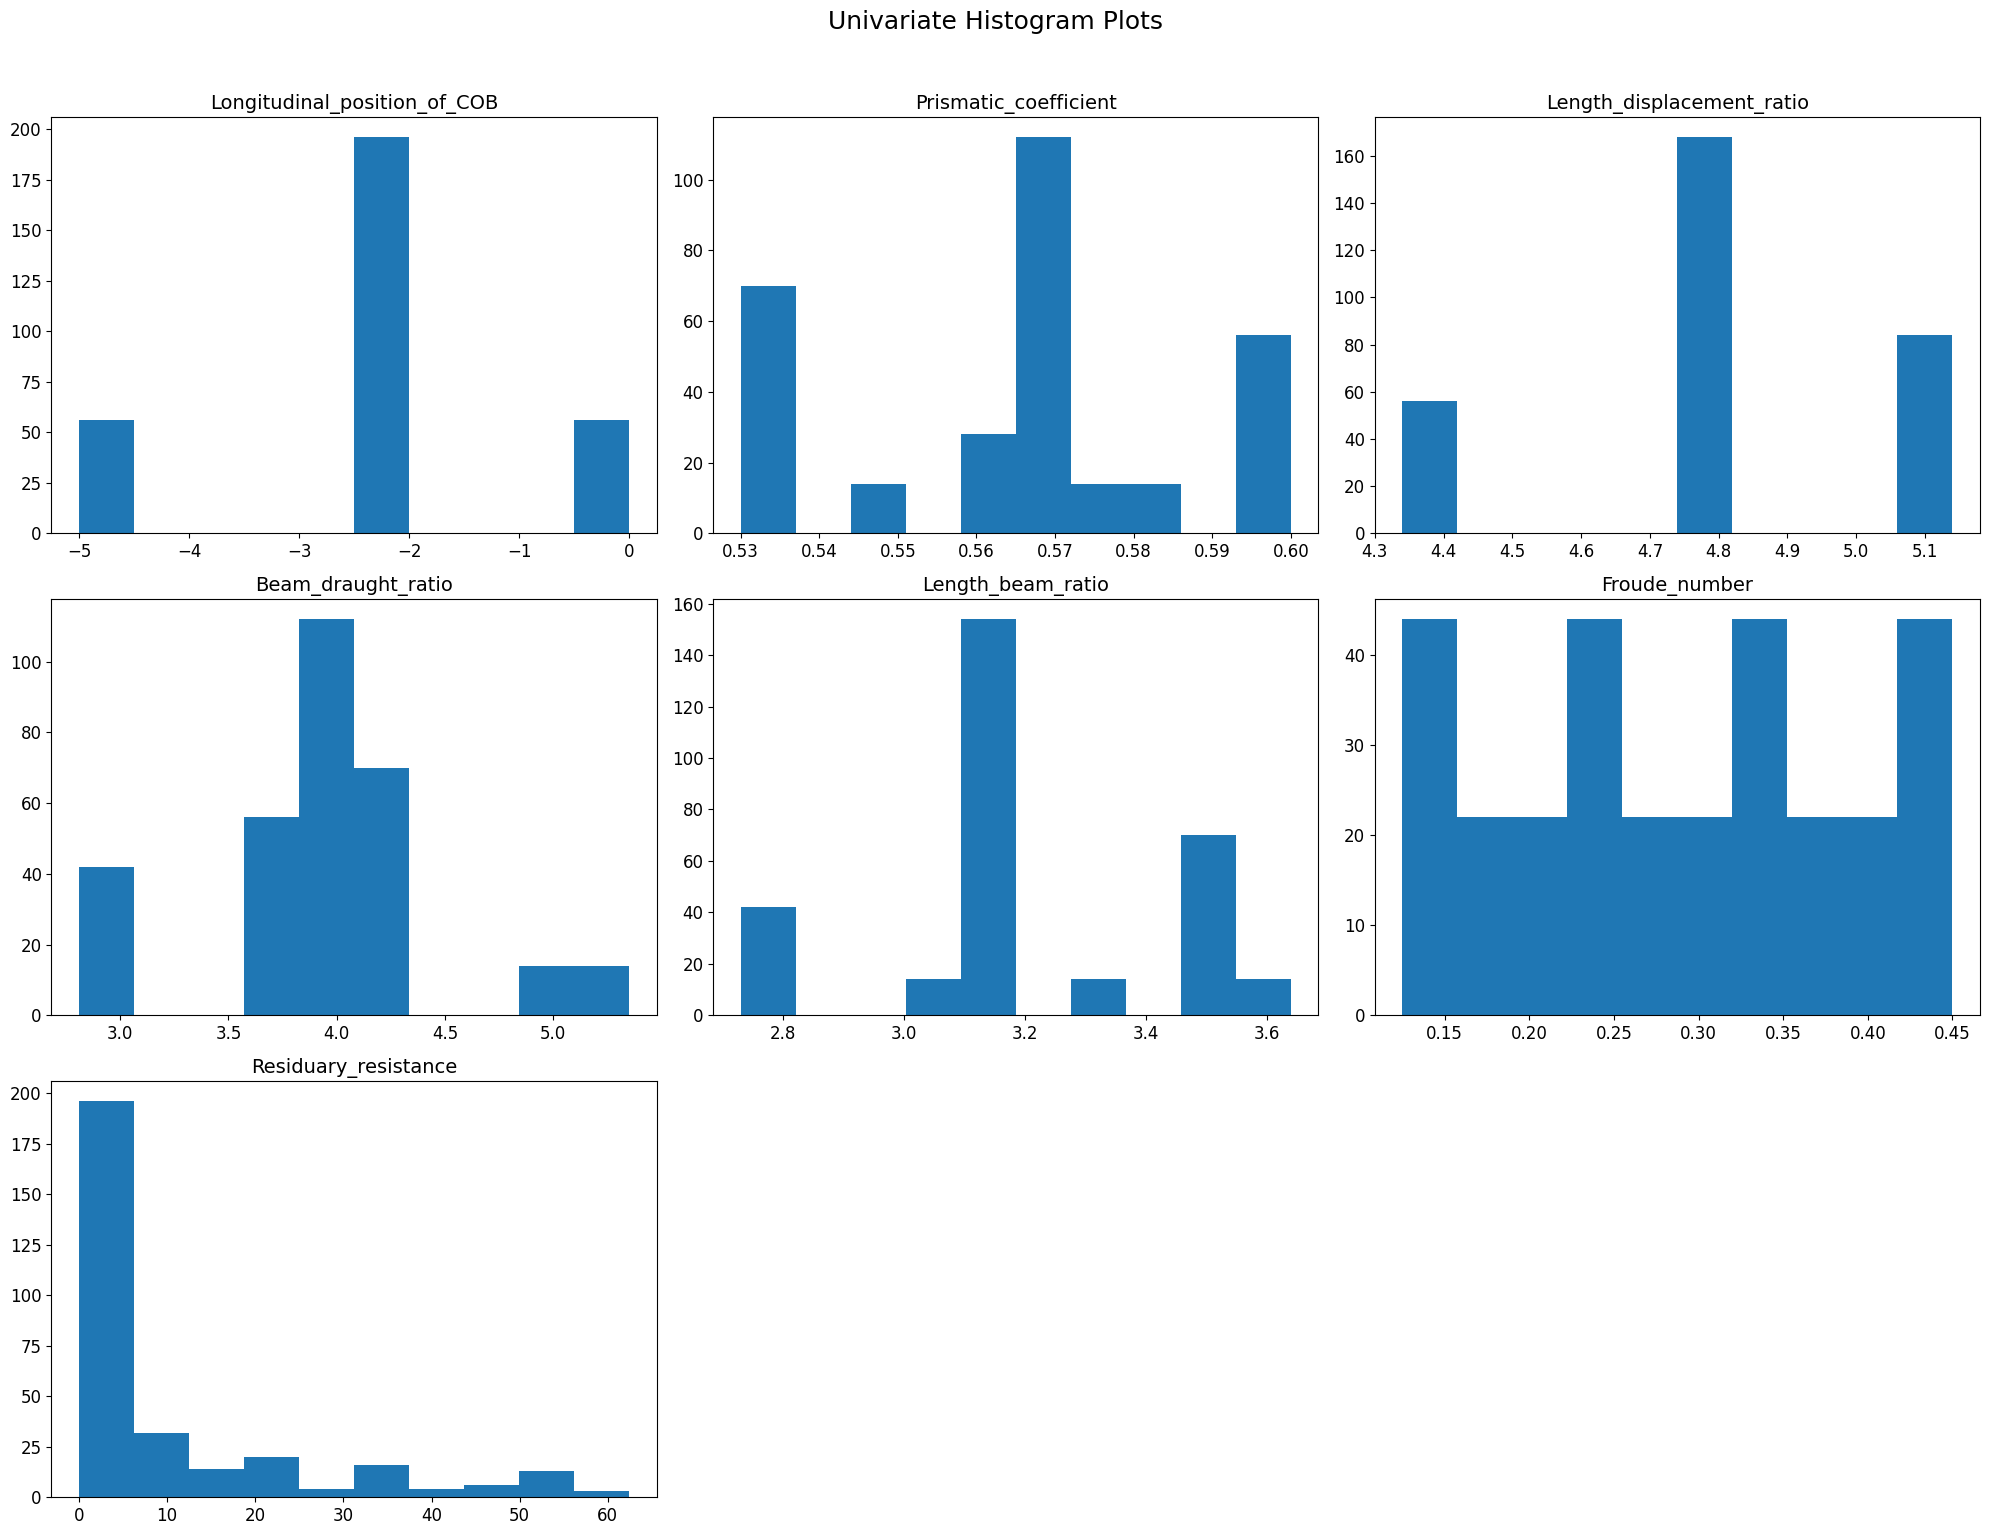

In [56]:
# Calculate the number of rows and columns for subplots
num_cols = df.shape[1]  # Number of columns in the DataFrame
num_rows = (num_cols + 2) // 3  # Calculate rows, ensuring enough space

# Create figure and axes with the correct number of subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(20, 15))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot histograms, ensuring you iterate over all columns
for i, col in enumerate(df.columns):
    df.hist(column=col,
            ax=axes[i],
            sharex=False,
            sharey=False,
            grid=False,
            xlabelsize=12,
            ylabelsize=12)
    axes[i].set_title(col, fontsize=14)

# Hide any unused subplots (if num_cols is not divisible by 3)
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Univariate Histogram Plots', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

| **Feature**                     | **Distribution**                                               | **Observation**                                                                 |
|---------------------------------|----------------------------------------------------------------|---------------------------------------------------------------------------------|
| Longitudinal_position_of_COB   | Strong peak around -2 to -2.5; smaller peaks near 0 and -5     | Most yachts have similar COB positions; some variation suggests different designs |
| Prismatic_coefficient          | Bimodal: peaks around 0.53 and 0.57                            | Mix of fine and fuller hull forms, likely balancing speed vs. stability         |
| Length_displacement_ratio      | Centered around 4.8                                            | Indicates moderately slender hulls; suitable for efficient speed                |
| Beam_draught_ratio             | Peak around 4.0                                                | Common yacht proportions; balance between stability and speed                   |
| Length_beam_ratio              | Strong peak at 3.2                                             | Reflects long, slender hulls optimized for hydrodynamic efficiency              |
| Froude_number                  | Uniformly distributed between 0.14 and 0.44                    | Wide range of operational speeds covered; suitable for general-purpose modeling |
| Residuary_resistance           | Right-skewed (long tail)                                       | Most cases have low resistance; some extreme outliers with high resistance      |

**Why Skewed Gaussian Distributions Are Problematic**

1. Many algorithms (e.g., linear regression, Gaussian Naive Bayes, PCA) assume data is normally distributed. Skew violates this assumption, leading to biased results.

2. Models like logistic regression and SVMs may underperform if features have heavy tails or outliers. Skewed data often has outliers, which can disproportionately influence model training (e.g., MSE loss in regression).


---
**Univariate Plots: Density**

---


Let’s look at the same distributions using density plots that smooth them out a bit.

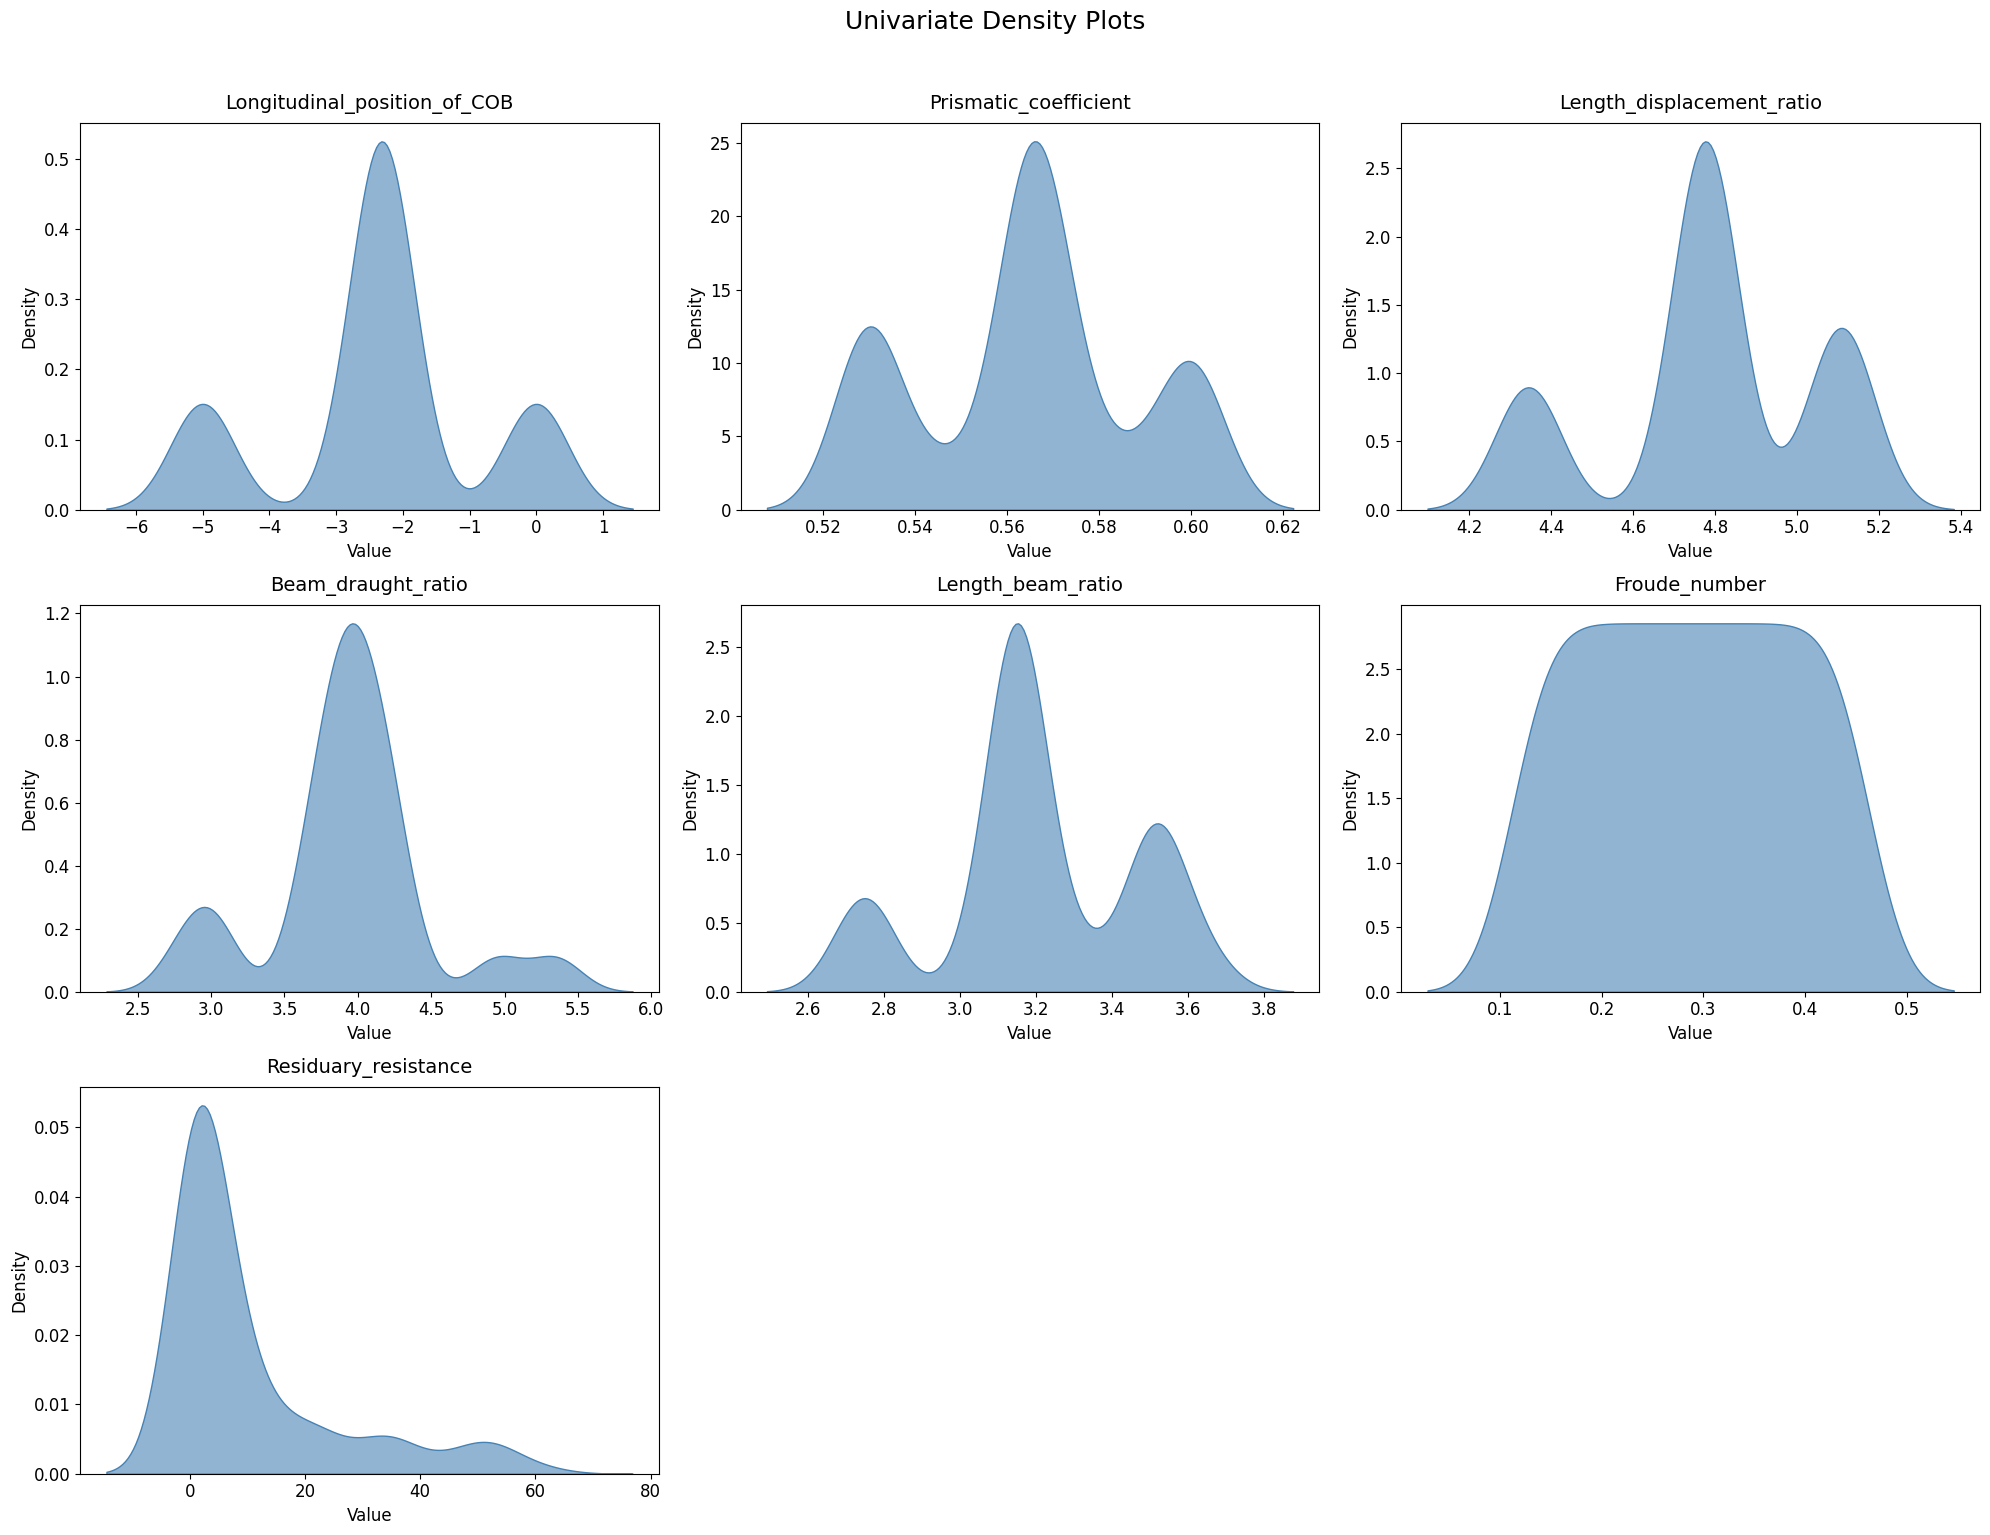

In [54]:

# Set up subplot grid
n_cols = 3
n_rows = int(np.ceil(len(df.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))  # Larger figure for big fonts

# Flatten axes array for easy iteration
axes = axes.ravel()

# Create density plots
for ax, column in zip(axes, df.columns):
    sns.kdeplot(data=df[column],
                ax=ax,
                fill=True,
                color='steelblue',
                alpha=0.6)

    # Formatting with your specified font sizes
    ax.set_title(column, fontsize=14, pad=10)
    ax.set_xlabel('Value', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(False)

# Hide empty subplots
for i in range(len(df.columns), len(axes)):
    axes[i].axis('off')

# Main title and layout
plt.suptitle('Univariate Density Plots', fontsize=18, y=1.02)
plt.tight_layout()  # Increased padding for large fonts
plt.show()

A brief analysis of the **Univariate Density Plots** in a table format:

| **Feature**                   | **Density Shape**                                           | **Insights**                                                                 |
|------------------------------|--------------------------------------------------------------|------------------------------------------------------------------------------|
| Longitudinal_position_of_COB | Trimodal distribution with main peak around -2              | Suggests three common hull design clusters based on COB position             |
| Prismatic_coefficient        | Trimodal, peaks near 0.53, 0.57, and 0.60                    | Reflects design variation between fine and fuller hulls                      |
| Length_displacement_ratio    | Trimodal, with peaks around 4.3 , 4,7 and 5.2.0                       | Indicates distinct yacht types (3?)    |
| Beam_draught_ratio           | Trimodal, strong peak near 4.0                                | Shows majority of yachts share similar proportions, with some outliers       |
| Length_beam_ratio            | Trimodal, dominant peak around 3.2                            | Common slender hull designs, but some variation present                      |
| Froude_number                | Uniform distribution with slight tapering at edges          | Dataset samples speeds evenly across range; good for modeling across regimes |
| Residuary_resistance         | Right-skewed with long tail                                 | Most yachts exhibit low resistance; some high-resistance cases as outliers   |

---
**Univariate Plots: Whisker Plot**

---

Let’s look at the data with box and whisker plots of each attribute.

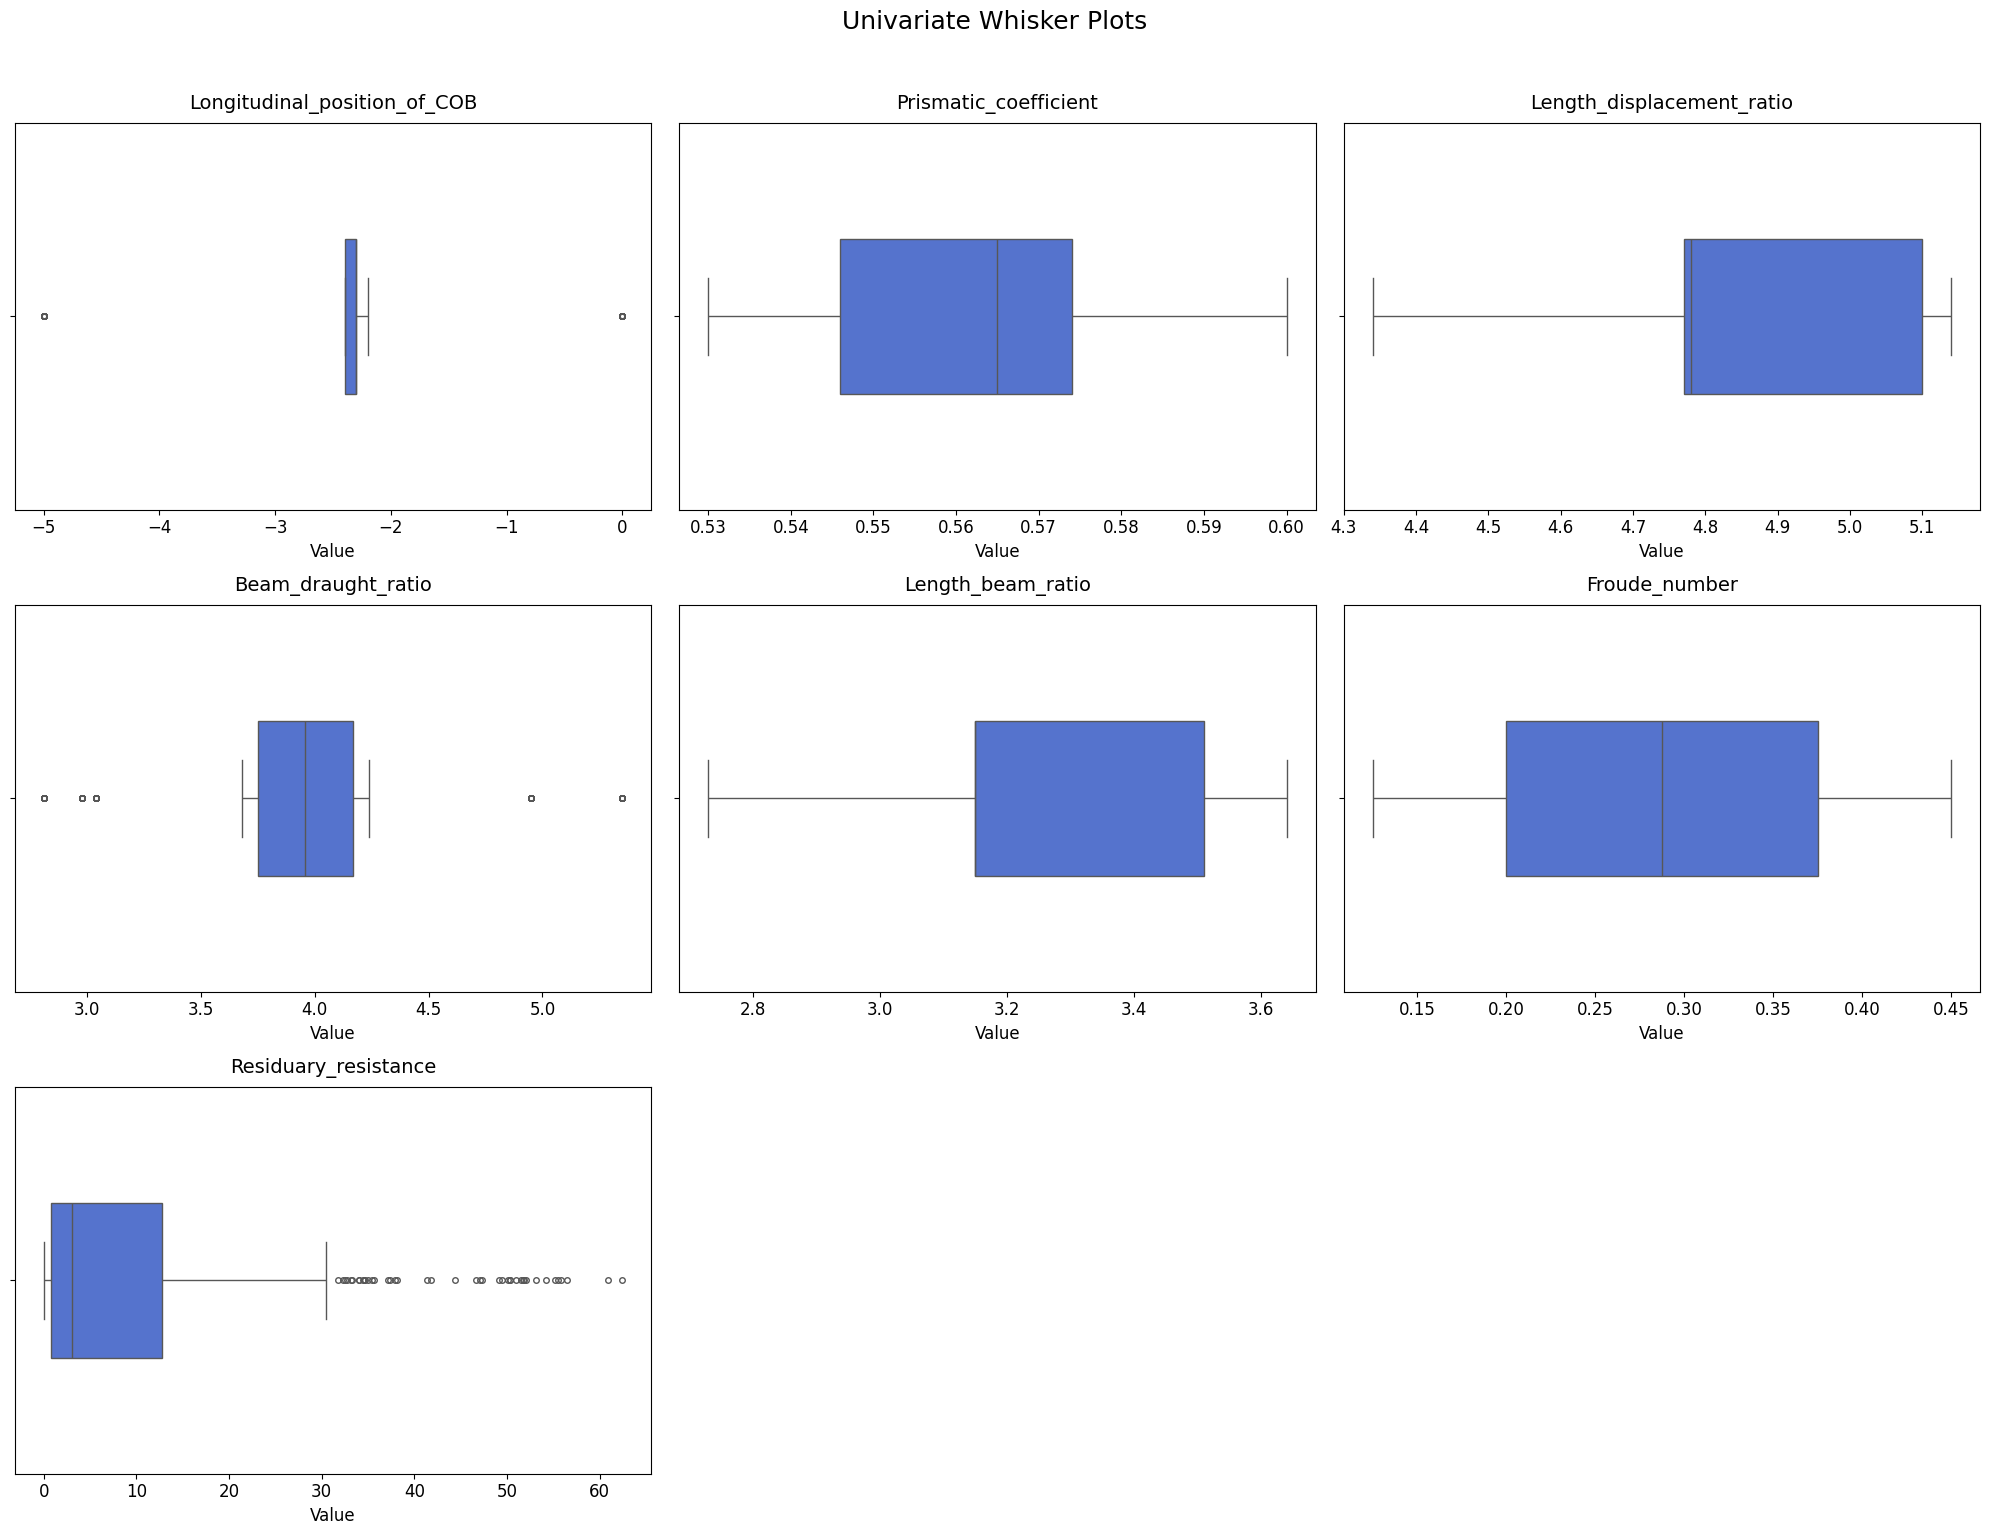

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up subplot grid
n_cols = 3
n_rows = int(np.ceil(len(df.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))

# Flatten axes array for easy iteration
axes = axes.ravel()

# Create box plots for each column
for ax, column in zip(axes, df.columns):
    sns.boxplot(x=df[column],
                ax=ax,
                color='royalblue',
                width=0.4,
                fliersize=4)  # Outlier marker size

    # Formatting with large fonts
    ax.set_title(column, fontsize=14, pad=10)
    ax.set_xlabel('Value', fontsize=12)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Remove y-axis for cleaner look (univariate)
    ax.set_ylabel('')
    ax.grid(False)

# Hide empty subplots
for i in range(len(df.columns), len(axes)):
    axes[i].axis('off')

# Main title and layout
plt.suptitle('Univariate Whisker Plots', fontsize=18, y=1.02)
plt.tight_layout()  # Extra padding for large fonts
plt.show()

| **Feature**                   | **Spread & Outliers**                                         | **Insights**                                                                 |
|------------------------------|---------------------------------------------------------------|------------------------------------------------------------------------------|
| Longitudinal_position_of_COB | Narrow IQR, several outliers on both sides                    | Highly concentrated COB positions; few designs deviate significantly         |
| Prismatic_coefficient        | Moderate spread, symmetric, no major outliers                 | Balanced variation in hull fullness; well-controlled range                   |
| Length_displacement_ratio    | Slightly right-skewed, wider IQR                              | Most yachts centered around 4.8–5.0, some variation toward higher values     |
| Beam_draught_ratio           | Moderate spread, multiple outliers                            | Consistent proportions but with occasional extreme hull forms                |
| Length_beam_ratio            | Moderate spread, few outliers                                 | Most yachts maintain similar slenderness ratios                              |
| Froude_number                | Uniform IQR, no significant outliers                          | Speed ratios are evenly distributed; no extreme operational cases            |
| Residuary_resistance         | Highly skewed right, many outliers                            | Most yachts show low resistance; frequent high-resistance anomalies exist    |


---
**Multivariate Plots: Correlation**

---

Now, let’s now take a look at the correlation between all of the numeric attributes.

In [66]:
# correlation
pd.set_option('display.precision', 2)
print(df.corr(method='pearson'))

                              Longitudinal_position_of_COB  \
Longitudinal_position_of_COB                      1.00e+00   
Prismatic_coefficient                            -8.61e-03   
Length_displacement_ratio                        -2.67e-03   
Beam_draught_ratio                                2.93e-03   
Length_beam_ratio                                -3.37e-03   
Froude_number                                    -3.51e-18   
Residuary_resistance                              1.93e-02   

                              Prismatic_coefficient  \
Longitudinal_position_of_COB              -8.61e-03   
Prismatic_coefficient                      1.00e+00   
Length_displacement_ratio                 -4.63e-02   
Beam_draught_ratio                         3.39e-01   
Length_beam_ratio                         -8.67e-02   
Froude_number                              2.91e-16   
Residuary_resistance                      -2.86e-02   

                              Length_displacement_ratio  Beam_

In text mode output format it is difficult to visualise the strongest correlations.

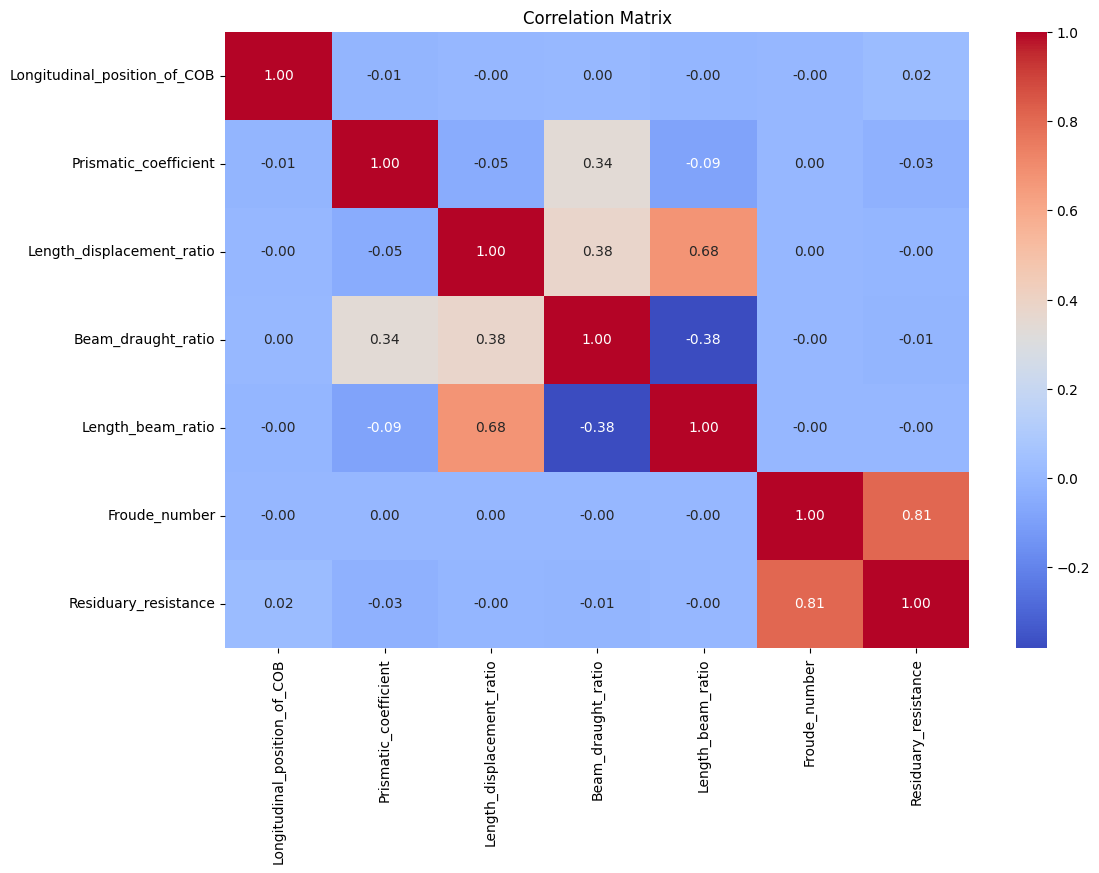

In [67]:
# Plotting correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

**Strong Correlations (|r| > 0.5)**
1. **Froude_number ↔ Residuary_resistance**  
   - **Correlation**: +0.81  
   - **Interpretation**: Very strong positive relationship. As the Froude number (speed parameter) increases, residuary resistance increases significantly. This is expected in naval architecture as higher speeds generate more wave resistance.

2. **Length_displacement_ratio ↔ Length_beam_ratio**  
   - **Correlation**: +0.68  
   - **Interpretation**: Moderate-strong positive link. Longer/narrower hulls (higher length-beam ratio) tend to have higher length-displacement ratios (slender designs).

3. **Length_displacement_ratio ↔ Beam_draught_ratio**  
   - **Correlation**: +0.38  
   - **Interpretation**: Moderate positive relationship. Slender hulls (high length-displacement) often have wider/shallower drafts.

4. **Beam_draught_ratio ↔ Length_beam_ratio**
  - **Correlation**: -0.38
  - **Interpretation**: Wider hulls (high beam-draught ratio) tend to be shorter relative to their width (low length-beam ratio).



Plotting the strongest correlation

Text(0.5, 1.0, 'Froude Number vs. Resistance (r = 0.81)')

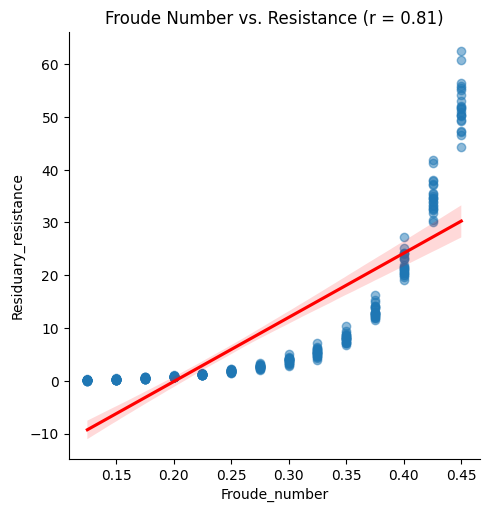

In [68]:
# Plot strongest relationship
sns.lmplot(data=df, x='Froude_number', y='Residuary_resistance',
           scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Froude Number vs. Resistance (r = 0.81)')

**Hydrodynamic Interpretation**

As Froude number (Fn) increases:

- Wave-making resistance grows exponentially

- Hull transitions from displacement to semi-planing mode

- Pressure drag becomes dominant

---
**Multivariate Plots: scatter plot**

---

Now we can look at the interactions between the variables. Let’s look at scatter plots of all
pairs of attributes. This can be helpful to spot structured relationships between input variables.